In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("D:/DATA/aitpune/college study thingy/dsbdal/prac_exam_questions/5-Linear_regression-food_delivery/Food_Delivery_Times.csv")

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [21]:
print("Columns:\n", df.columns)

# Target
y = df["Delivery_Time_min"]

# Predictors
X = df.drop("Delivery_Time_min", axis=1)

print("\nPredictors:\n", X.columns)
print("\nTarget: Delivery_Time_min")

Columns:
 Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')

Predictors:
 Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs'],
      dtype='str')

Target: Delivery_Time_min


In [22]:
df = df.drop("Order_ID", axis=1)

In [23]:
print(df.isnull().sum())

Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [24]:
# Fill numeric with mean
df = df.fillna(df.mean(numeric_only=True))

In [25]:
df = pd.get_dummies(df, drop_first=True)

In [26]:
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]


--- Feature: Distance_km ---
MSE: 158.16196727280166
RMSE: 12.576246151884975
R2: 0.6471386683659509


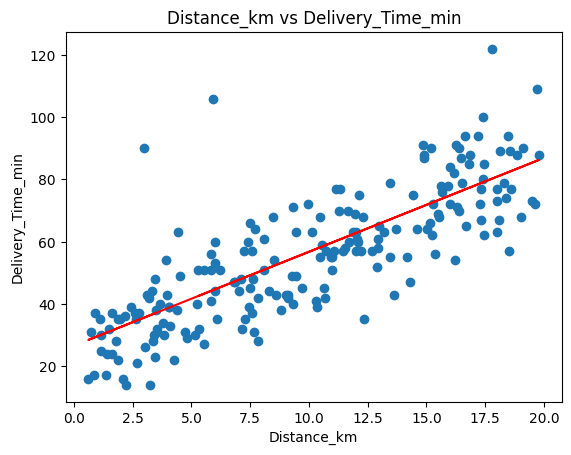


--- Feature: Preparation_Time_min ---
MSE: 407.4444922711882
RMSE: 20.185254327632045
R2: 0.09098623019913477


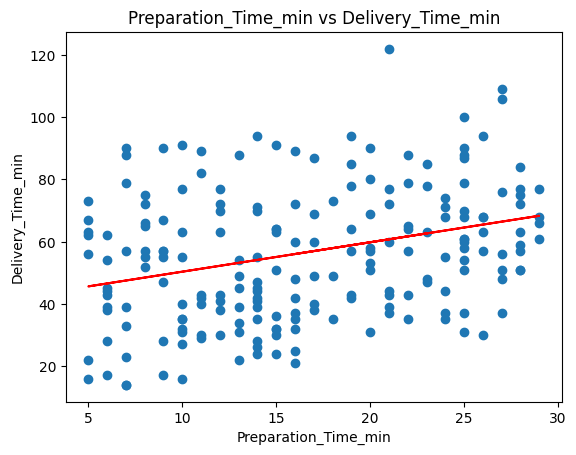


--- Feature: Courier_Experience_yrs ---
MSE: 447.3820774033949
RMSE: 21.151408402359284
R2: 0.0018849771292884787


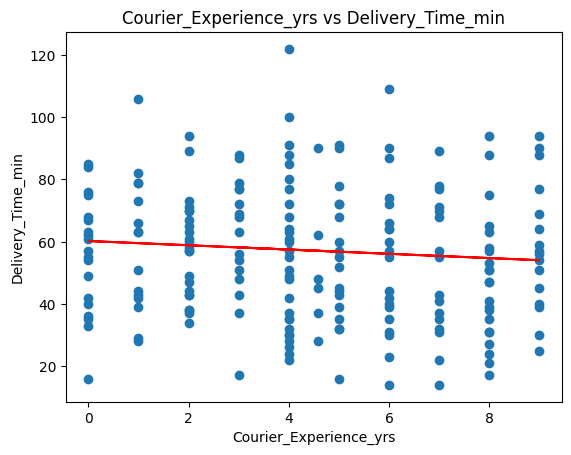


--- Feature: Weather_Foggy ---
MSE: 449.1004012784823
RMSE: 21.191989082634088
R2: -0.001948624976179314


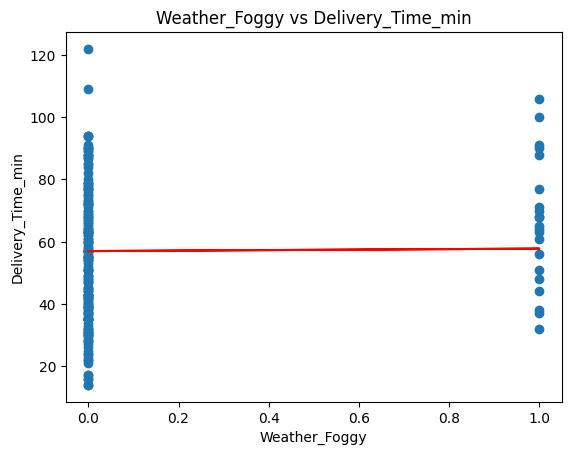


--- Feature: Weather_Rainy ---
MSE: 451.131032258862
RMSE: 21.23984539159506
R2: -0.0064789881484976775


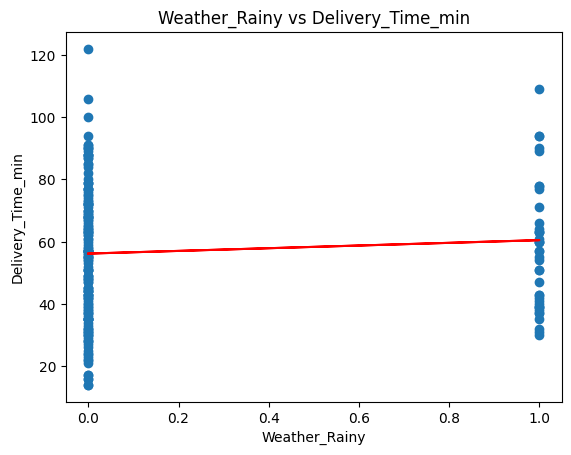


--- Feature: Weather_Snowy ---
MSE: 444.68761615784723
RMSE: 21.08761760270342
R2: 0.007896353944679024


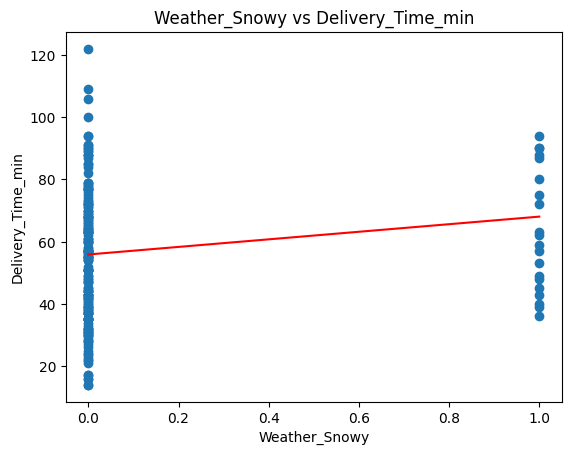


--- Feature: Weather_Windy ---
MSE: 451.7788594135803
RMSE: 21.25509020008102
R2: -0.007924298651548645


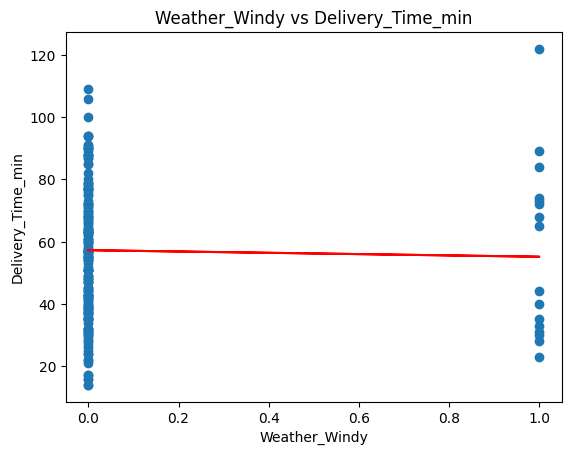


--- Feature: Traffic_Level_Low ---
MSE: 440.45914768457936
RMSE: 20.987118613201275
R2: 0.017330120114749104


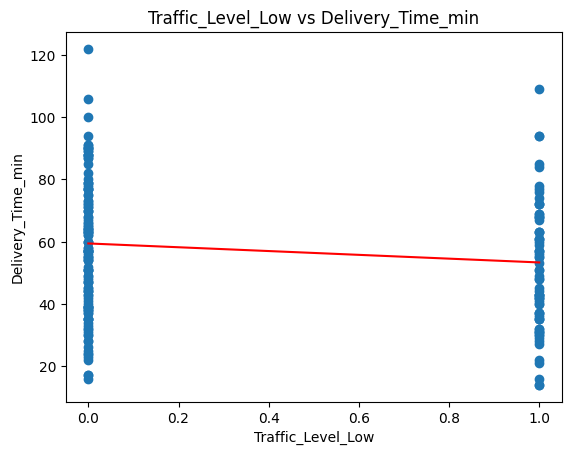


--- Feature: Traffic_Level_Medium ---
MSE: 449.92506503611366
RMSE: 21.211437128023967
R2: -0.003788460157074791


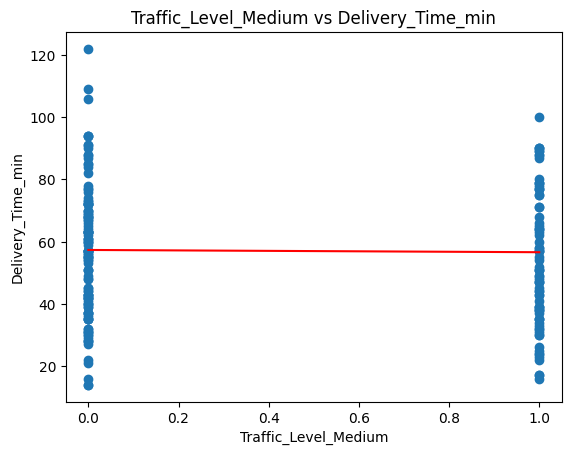


--- Feature: Time_of_Day_Evening ---
MSE: 450.46230428864243
RMSE: 21.22409725497512
R2: -0.004987047664059885


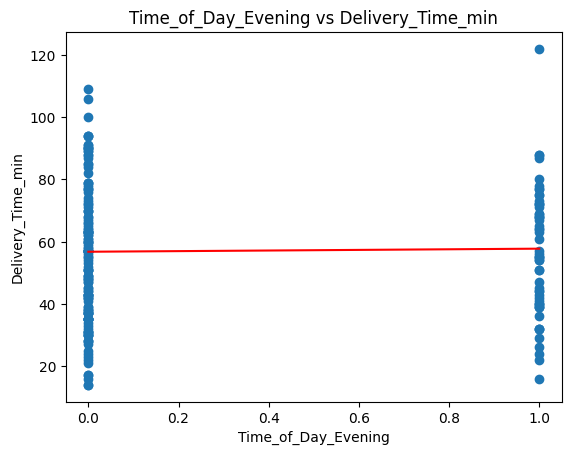


--- Feature: Time_of_Day_Morning ---
MSE: 450.33712988236965
RMSE: 21.221148175402046
R2: -0.004707781994534477


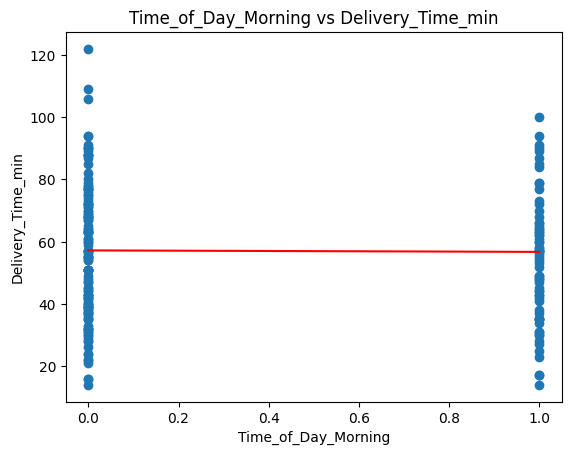


--- Feature: Time_of_Day_Night ---
MSE: 451.24091492189075
RMSE: 21.24243194462185
R2: -0.00672413774715519


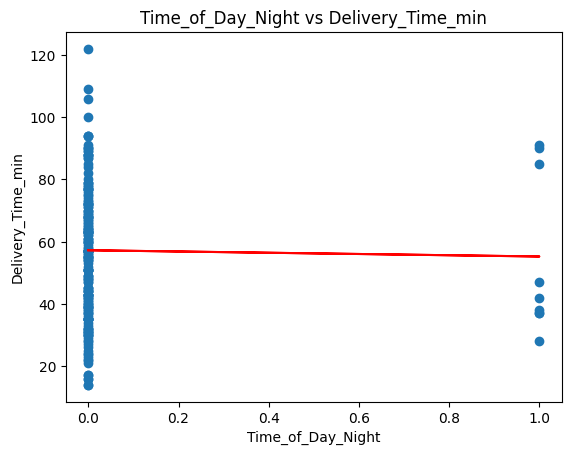


--- Feature: Vehicle_Type_Car ---
MSE: 449.58368962954444
RMSE: 21.203388635535227
R2: -0.003026847345687811


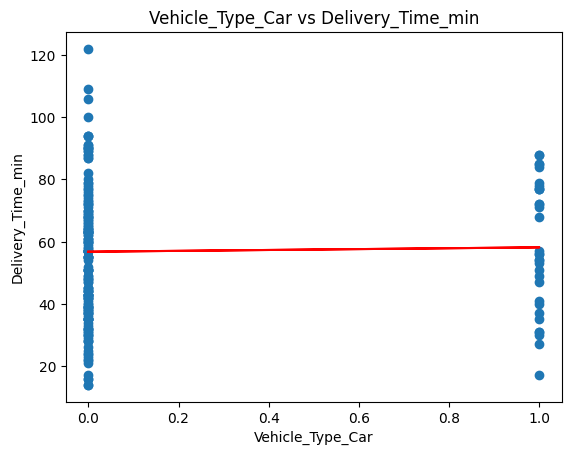


--- Feature: Vehicle_Type_Scooter ---
MSE: 451.9587939448695
RMSE: 21.25932251848279
R2: -0.00832573484643473


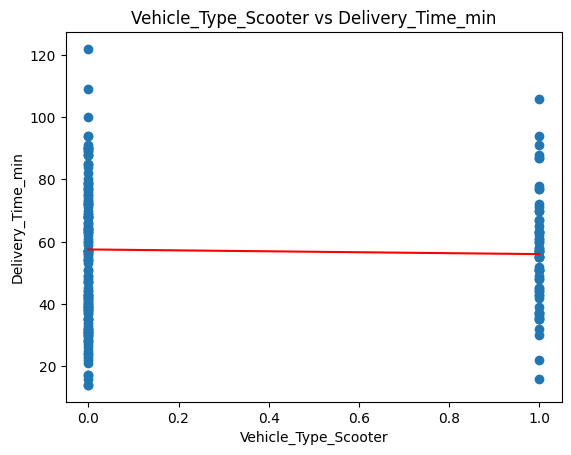

In [27]:
for col in X.columns:
    
    print(f"\n--- Feature: {col} ---")
    
    X_single = X[[col]]
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_single, y, test_size=0.2, random_state=42
    )
    
    # Model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    
    # Plot
    plt.figure()
    plt.scatter(X_test, y_test)
    plt.plot(X_test, y_pred, color='red')
    
    plt.xlabel(col)
    plt.ylabel("Delivery_Time_min")
    plt.title(f"{col} vs Delivery_Time_min")
    
    plt.show()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [29]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("\nMultiple Linear Regression")
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R2:", r2_multi)


Multiple Linear Regression
MSE: 79.23417763012154
RMSE: 8.90135819019331
R2: 0.8232275564626125


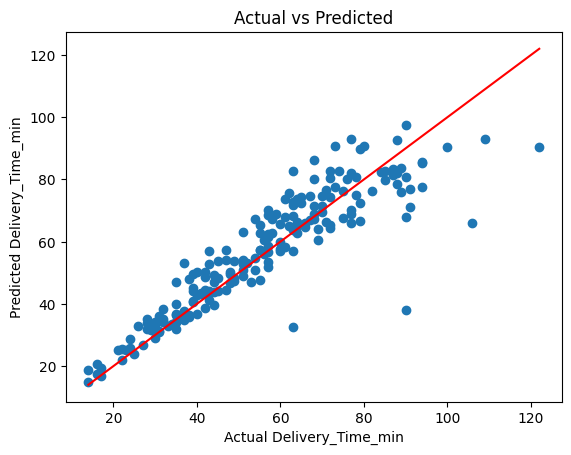

In [30]:
plt.scatter(y_test, y_pred_multi)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Delivery_Time_min")
plt.ylabel("Predicted Delivery_Time_min")
plt.title("Actual vs Predicted")

plt.show()